In [1]:
import os
import glob
import sys
import pandas as pd
import numpy as np

INPUT_FOLDER = "Simulated_Waveforms"

# Recursively find all CSV files in the Simulated_Waveforms directory
search_path = os.path.join(INPUT_FOLDER, '*.csv')
channel_files = glob.glob(search_path)

if not channel_files:
    print(f"No channel files found in {INPUT_FOLDER}")
    sys.exit()
    
print(f"Loading {len(channel_files)} channel files into memory...")

# dictionary containing the time and signal data for each channel
# format: {filename: pd.DataFrame, shape = (N, 3), columns = ['time', 'signal', 'PD number']}
channel_dataframes = {}
for filepath in channel_files:
    filename = os.path.basename(filepath)
    try:
        # Load the CSV file without headers
        df = pd.read_csv(filepath, header=None)
        channel_dataframes[filename] = df
        print(f"  Loaded {filename}")
    except Exception as e:
        print(f"  Error loading {filename}: {e}")
        
if not channel_dataframes:
    print("No dataframes loaded. Exiting.")
    sys.exit()

Loading 4 channel files into memory...
  Loaded Ch1.csv
  Loaded Ch2.csv
  Loaded Ch3.csv
  Loaded Ch4.csv


In [2]:
import scipy.signal as signal
import numpy as np

def calculate_lag(env1, env2):
    # inputs are two numpy 1D arrays, and the sampling frequency
    # env 1 is sensor1, env2 is sensor2,3,4

    # value of first index in correlation array is the correlation when env2 is moved to the leftmost position
    correlation = signal.correlate(env1, env2, mode='full')
    
    # first index in lags is the negative length of env2 + 1 (corresponding to env2 being moved to the leftmost position)
    lags = signal.correlation_lags(env1.size, env2.size, mode='full')
    
    # Find lag with maximum correlation (restricted to middle 2000 samples)
    mid = len(correlation) // 2
    start_idx = max(0, mid - 1000)
    end_idx = min(len(correlation), mid + 1000)
    lag = lags[start_idx:end_idx][np.argmax(correlation[start_idx:end_idx])]

    '''
    positive tdoa means env2 is to the right of env1
    i.e. signal takes longer time to reach sensor 2,3,4 than 1
    thus positive tdoa means env2 is moved left, meaning negative lag
    '''

    return lag


In [3]:
import pandas as pd
import Envelope_Analysis as EA
import numpy as np
from scipy.optimize import least_squares
import scipy.signal as signal

INDICES_FILE = "Waveform_Analysis.csv"
SAMPLING_FREQ = 5e9
C_VELOCITY = 3e8 # Speed of light in m/s (adjust if in different medium)

# Sensor coordinates from Generate_Waveforms.ipynb
sensors = np.array([
    [1.0, 3.0, 1.4], # S1 (Reference Channel 1)
    [1.0, 5.0, 1.8], # S2
    [1.0, 7.0, 1.4], # S3
    [1.0, 9.0, 1.8]  # S4
])

Void_coords = np.array([3.7, 5.0, 0.1])
Incision_coords = np.array([3.7, 7.0, 0.1])

PD_coords = np.array([
    Void_coords,
    Incision_coords
])

TDOA_results = []

indices_df = pd.read_csv(INDICES_FILE)
    
if indices_df.empty:
    print("No isolated waveforms found in indices file.")
    

# Ensure needed columns exist
if not all(col in indices_df.columns for col in ['input filename', 'PD number','start idx', 'end idx', 'Grouping_Envelope_Analysis']):
    print(f"Error: Input CSV must contain ['input filename', 'PD number','start idx', 'end idx', 'Grouping_Envelope_Analysis'] columns.")
    

groups = indices_df[indices_df['Grouping_Envelope_Analysis'] > 0]['Grouping_Envelope_Analysis'].unique()

warning = ''
for group_id in sorted(groups):
    df_onegroup = indices_df[indices_df['Grouping_Envelope_Analysis'] == group_id]
    df_onegroup = df_onegroup[['input filename', 'PD number','start idx', 'end idx', 'Grouping_Envelope_Analysis']]
    valuecounts = df_onegroup['input filename'].value_counts()

    if valuecounts.max() > 1:
        warning = "One or more groups has multiple waveforms for the same channel."
    if not all(df_onegroup['input filename'].str.contains(filename).any() for filename in ['Ch1', 'Ch2', 'Ch3', 'Ch4']):
        warning = "One or more groups is missing at least one waveform from at least one channel."
        continue

    df_onegroup = df_onegroup.drop_duplicates(subset=['input filename'], keep='first')

    if (df_onegroup['PD number'].unique().size == 1) & (df_onegroup['PD number'].iloc[0] != -1):
        pd_number = df_onegroup['PD number'].iloc[0]
    else:
        pd_number = -1

    first_signal = df_onegroup[df_onegroup['input filename'].str.contains('Ch1')].iloc[0]
    input_filename = first_signal['input filename']
    start_idx = first_signal['start idx']
    end_idx = first_signal['end idx']
    start_time_1 = channel_dataframes[input_filename].iloc[start_idx,0]
    
    raw_sig1 = EA.load_waveform(input_filename, start_idx, end_idx, channel_dataframes)
    env1 = EA.process_envelope(raw_sig1, sigma_samples=12)

    tdoa = [0,0,0]
    for index, next_signal in df_onegroup.iterrows():
        if 'ch1' in next_signal['input filename'].lower():
            continue
        
        input_filename = next_signal['input filename']
        start_idx = next_signal['start idx']
        end_idx = next_signal['end idx']
    
        raw_sig2 = EA.load_waveform(input_filename, start_idx, end_idx, channel_dataframes)
        env2 = EA.process_envelope(raw_sig2, sigma_samples=12)
        start_time_2 = channel_dataframes[input_filename].iloc[start_idx,0]

        if 'ch2' in next_signal['input filename'].lower():
            lag = calculate_lag(env1, env2)
            total_lag = start_time_2 - start_time_1 - lag/SAMPLING_FREQ
            tdoa[0] = total_lag
        elif 'ch3' in next_signal['input filename'].lower():
            lag = calculate_lag(env1, env2)
            total_lag = start_time_2 - start_time_1 - lag/SAMPLING_FREQ
            tdoa[1] = total_lag
        elif 'ch4' in next_signal['input filename'].lower():
            lag = calculate_lag(env1, env2)
            total_lag = start_time_2 - start_time_1 - lag/SAMPLING_FREQ
            tdoa[2] = total_lag
    
    # estimated_pos = ModSec.modsecant(sensors[0],sensors[1],sensors[2],sensors[3],tdoa[0],tdoa[1],tdoa[2])
    if pd_number == 'void':
        idx = 0
    elif pd_number == 'incision':
        idx = 1
    TDOA_results.append({
        'Group': group_id,
        'TDOA_21': tdoa[0],
        'TDOA_31': tdoa[1],
        'TDOA_41': tdoa[2],
        'Actual_X': PD_coords[idx][0] if pd_number != -1 else -1000,
        'Actual_Y': PD_coords[idx][1] if pd_number != -1 else -1000,
        'Actual_Z': PD_coords[idx][2] if pd_number != -1 else -1000,
        # 'Est_X': estimated_pos[0],
        # 'Est_Y': estimated_pos[1],
        # 'Est_Z': estimated_pos[2]
    })

if TDOA_results:
    final_df = pd.DataFrame(TDOA_results)
    print("\nFinal Localization Results:")
    display(final_df)   

TDOA_results_df = pd.DataFrame(TDOA_results)
TDOA_results_df.to_csv('TDOA_Results.csv', index=False)



Final Localization Results:


,Group,TDOA_21,TDOA_31,TDOA_41,Actual_X,Actual_Y,Actual_Z
0,1,-1.600000e-08,-1.470000e-08,-3.470000e-08,-1000,-1000,-1000
1,2,-1.170000e-08,-5.000000e-09,-2.530000e-08,-1000,-1000,-1000
2,3,2.050000e-08,7.100000e-09,4.170000e-08,-1000,-1000,-1000
3,4,2.530000e-08,-2.920000e-08,-2.370000e-08,-1000,-1000,-1000
4,5,-4.000000e-09,-2.110000e-08,1.140000e-08,-1000,-1000,-1000
5,6,-1.700000e-09,2.870000e-08,-3.309000e-07,-1000,-1000,-1000


# Printing out the TDOA results for MATLAB PSO

In [4]:
# Iterate through the DataFrame and print specified columns comma+space separated
for _, row in TDOA_results_df.iterrows():
    print(f"{row['Actual_X']}, {row['Actual_Y']}, {row['Actual_Z']}, {row['TDOA_21']}, {row['TDOA_31']}, {row['TDOA_41']}")

-1000.0, -1000.0, -1000.0, -1.5999999999999998e-08, -1.4699999999999994e-08, -3.47e-08
-1000.0, -1000.0, -1000.0, -1.1699999999999996e-08, -4.9999999999999985e-09, -2.53e-08
-1000.0, -1000.0, -1000.0, 2.0499999999999998e-08, 7.099999999999998e-09, 4.17e-08
-1000.0, -1000.0, -1000.0, 2.5299999999999998e-08, -2.92e-08, -2.3699999999999997e-08
-1000.0, -1000.0, -1000.0, -3.999999999999998e-09, -2.1100000000000004e-08, 1.1400000000000003e-08
-1000.0, -1000.0, -1000.0, -1.7000000000000003e-09, 2.8700000000000002e-08, -3.3090000000000003e-07


In [5]:
df = pd.read_csv('converted_data_envelope_analysis.csv', header=None)
TDOA_results_df[['PSO_X','PSO_Y','PSO_Z']] = df.iloc[:,3:6].values
TDOA_results_df[['PSO_Percentage_Error', 'PSO_Euclidean_Error']] = df.iloc[:,0:2].values

TDOA_results_df.to_csv('TDOA_Results.csv', index=False)

In [6]:
from sklearn.cluster import DBSCAN

epsilon = 1
min_samples = 2

X = TDOA_results_df[['PSO_X', 'PSO_Y', 'PSO_Z']].values

dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)

clusters = dbscan.fit_predict(X)

TDOA_results_df['cluster (PSO -> DBSCAN)'] = clusters

TDOA_results_df.to_csv('TDOA_Results.csv', index=False)

Generating 3D Cluster Plot...


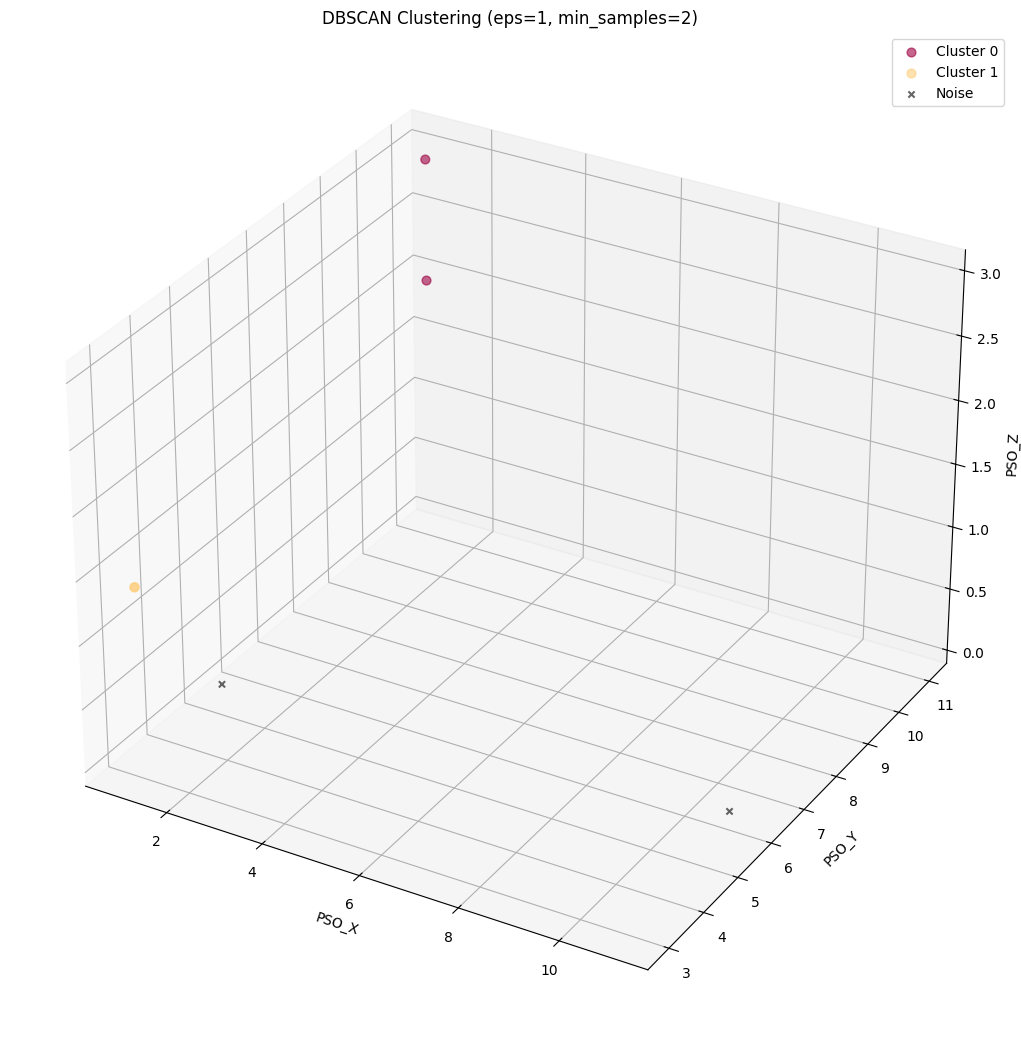

In [7]:
import matplotlib.pyplot as plt

print("Generating 3D Cluster Plot...")
    
fig = plt.figure(figsize=(15, 13))
ax = fig.add_subplot(111, projection='3d')

# Get unique labels
unique_labels = set(clusters)

# Define colors (using a colormap)
colors = plt.cm.Spectral(np.linspace(0, 4, len(unique_labels)*4))

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise, similar to unclassified points in paper figures
        col = [0, 0, 0, 1]
        label = "Noise"
        marker = 'x'
        size = 20
    else:
        label = f"Cluster {k}"
        marker = 'o'
        size = 40

    # Select data for this cluster
    class_member_mask = (clusters == k)
    xyz = X[class_member_mask]
    
    ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], 
                c=[col], s=size, label=label, marker=marker, alpha=0.6)

ax.set_xlabel('PSO_X')
ax.set_ylabel('PSO_Y')
ax.set_zlabel('PSO_Z')
ax.set_title(f'DBSCAN Clustering (eps={epsilon}, min_samples={min_samples})')
ax.legend()

plt.show()

In [8]:
# Calculate the mean PSO_X, PSO_Y, and PSO_Z for each cluster
pso_cluster_means = TDOA_results_df.groupby('cluster (PSO -> DBSCAN)')[['PSO_X', 'PSO_Y', 'PSO_Z']].mean()

# Display the results
print(pso_cluster_means)

                         PSO_X   PSO_Y  PSO_Z
cluster (PSO -> DBSCAN)                      
-1                         6.0   5.475   0.10
 0                         1.0  11.000   2.47
 1                         1.0   2.995   1.40


In [9]:
'''
import PSO as pso
# PSO
temp1 = TDOA_results_df[['Actual_X', 'Actual_Y', 'Actual_Z']].to_numpy()
temp2 = TDOA_results_df[['TDOA_21', 'TDOA_31', 'TDOA_41']].to_numpy()
data_predict = np.concatenate((temp1, temp2), axis=1)
results = pso.pso_algorithm(data_predict)
'''

"\nimport PSO as pso\n# PSO\ntemp1 = TDOA_results_df[['Actual_X', 'Actual_Y', 'Actual_Z']].to_numpy()\ntemp2 = TDOA_results_df[['TDOA_21', 'TDOA_31', 'TDOA_41']].to_numpy()\ndata_predict = np.concatenate((temp1, temp2), axis=1)\nresults = pso.pso_algorithm(data_predict)\n"

In [10]:
'''
pso_results_df = pd.DataFrame(results)


pso_coordinates_df = pd.DataFrame(pso_results_df['estimated_location'].to_list(), columns=['PSO_X', 'PSO_Y', 'PSO_Z'])

pso_coordinates_df['PSO_oercentage_error'] = pso_results_df['percentage_error']
pso_coordinates_df['PSO_euclidean_distance'] = pso_results_df['euclidean_distance']

TDOA_results_df = pd.concat([TDOA_results_df, pso_coordinates_df], axis=1)

TDOA_results_df.to_csv('TDOA_Results.csv', index=False)
'''




"\npso_results_df = pd.DataFrame(results)\n\n\npso_coordinates_df = pd.DataFrame(pso_results_df['estimated_location'].to_list(), columns=['PSO_X', 'PSO_Y', 'PSO_Z'])\n\npso_coordinates_df['PSO_oercentage_error'] = pso_results_df['percentage_error']\npso_coordinates_df['PSO_euclidean_distance'] = pso_results_df['euclidean_distance']\n\nTDOA_results_df = pd.concat([TDOA_results_df, pso_coordinates_df], axis=1)\n\nTDOA_results_df.to_csv('TDOA_Results.csv', index=False)\n"

In [11]:
from sklearn.cluster import DBSCAN

epsilon = 2e-9
min_samples = 2

X = TDOA_results_df[['TDOA_21', 'TDOA_31', 'TDOA_41']].values

dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)

clusters = dbscan.fit_predict(X)

TDOA_results_df['cluster (DBSCAN -> PSO)'] = clusters

TDOA_results_df.to_csv('TDOA_Results.csv', index=False)


Generating 3D Cluster Plot...


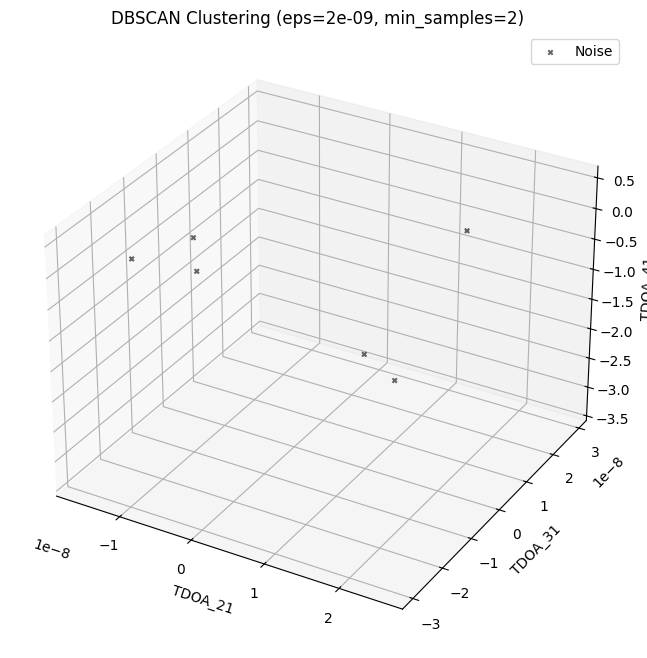

In [12]:
import matplotlib.pyplot as plt

print("Generating 3D Cluster Plot...")
    
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Get unique labels
unique_labels = set(clusters)

# Define colors (using a colormap)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise, similar to unclassified points in paper figures
        col = [0, 0, 0, 1]
        label = "Noise"
        marker = 'x'
        size = 10
    else:
        label = f"Cluster {k}"
        marker = 'o'
        size = 20

    # Select data for this cluster
    class_member_mask = (clusters == k)
    xyz = X[class_member_mask]
    
    ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], 
                c=[col], s=size, label=label, marker=marker, alpha=0.6)

ax.set_xlabel('TDOA_21')
ax.set_ylabel('TDOA_31')
ax.set_zlabel('TDOA_41')
ax.set_title(f'DBSCAN Clustering (eps={epsilon}, min_samples={min_samples})')
ax.legend()

plt.show()

In [13]:
# Calculate mean TDOA and Actual coordinates for each cluster
cluster_means = TDOA_results_df[TDOA_results_df['cluster (DBSCAN -> PSO)'] != -1].groupby('cluster (DBSCAN -> PSO)').mean()

# Prepare data for PSO: Actual_X, Actual_Y, Actual_Z, TDOA_21, TDOA_31, TDOA_41
# The columns in cluster_means will be Group, TDOA_21, TDOA_31, TDOA_41, Actual_X, Actual_Y, Actual_Z
pso_input_data = cluster_means[['Actual_X', 'Actual_Y', 'Actual_Z', 'TDOA_21', 'TDOA_31', 'TDOA_41']].to_numpy()

print(f"Running PSO for {len(cluster_means)} clusters...")
import PSO as pso
cluster_pso_results = pso.pso_algorithm(pso_input_data)

# Convert results to DataFrame for display
cluster_pso_df = pd.DataFrame(cluster_pso_results)
# Add cluster ID back
cluster_pso_df['cluster'] = cluster_means.index.tolist()

print("\nPSO Results for Cluster Means:")
display(cluster_pso_df[['cluster', 'estimated_location', 'true_location', 'euclidean_distance', 'percentage_error']])


Running PSO for 0 clusters...


KeyboardInterrupt: 

# Section 2:
# TDOA and localization for results of PCA

In [14]:
import pandas as pd
import Envelope_Analysis as EA
import numpy as np
from scipy.optimize import least_squares
import scipy.signal as signal

INDICES_FILE = "Waveform_Analysis.csv"
SAMPLING_FREQ = 5e9
C_VELOCITY = 3e8 # Speed of light in m/s (adjust if in different medium)

# Sensor coordinates from Generate_Waveforms.ipynb
sensors = np.array([
    [1.0, 3.0, 1.4], # S1 (Reference Channel 1)
    [1.0, 5.0, 1.8], # S2
    [1.0, 7.0, 1.4], # S3
    [1.0, 9.0, 1.8]  # S4
])

Void_coords = np.array([3.7, 5.0, 0.1])
Incision_coords = np.array([3.7, 7.0, 0.1])

PD_coords = np.array([
    Void_coords,
    Incision_coords
])

TDOA_results = []

indices_df = pd.read_csv(INDICES_FILE)
    
if indices_df.empty:
    print("No isolated waveforms found in indices file.")
    

# Ensure needed columns exist
if not all(col in indices_df.columns for col in ['input filename', 'PD number','start idx', 'end idx', 'Simple PCA Feature Cluster ID']):
    print(f"Error: Input CSV must contain ['input filename', 'PD number','start idx', 'end idx', 'Simple PCA Feature Cluster ID'] columns.")
    

groups = indices_df[indices_df['Simple PCA Feature Cluster ID'] > 0]['Simple PCA Feature Cluster ID'].unique()

warning = ''
for group_id in sorted(groups):
    df_onegroup = indices_df[indices_df['Simple PCA Feature Cluster ID'] == group_id]
    df_onegroup = df_onegroup[['input filename', 'PD number','start idx', 'end idx', 'Simple PCA Feature Cluster ID']]
    valuecounts = df_onegroup['input filename'].value_counts()

    if valuecounts.max() > 1:
        warning = "One or more groups has multiple waveforms for the same channel."
    if not all(df_onegroup['input filename'].str.contains(filename).any() for filename in ['Ch1', 'Ch2', 'Ch3', 'Ch4']):
        warning = "One or more groups is missing at least one waveform from at least one channel."
        continue

    df_onegroup = df_onegroup.drop_duplicates(subset=['input filename'], keep='first')

    if (df_onegroup['PD number'].unique().size == 1) & (df_onegroup['PD number'].iloc[0] != 0):
        pd_number = df_onegroup['PD number'].iloc[0]
    else:
        pd_number = -1

    first_signal = df_onegroup[df_onegroup['input filename'].str.contains('Ch1')].iloc[0]
    input_filename = first_signal['input filename']
    start_idx = first_signal['start idx']
    end_idx = first_signal['end idx']
    start_time_1 = channel_dataframes[input_filename].iloc[start_idx,0]
    
    raw_sig1 = EA.load_waveform(input_filename, start_idx, end_idx, channel_dataframes)
    env1 = EA.process_envelope(raw_sig1, sigma_samples=12)

    tdoa = [0,0,0]
    for index, next_signal in df_onegroup.iterrows():
        if 'ch1' in next_signal['input filename'].lower():
            continue
        
        input_filename = next_signal['input filename']
        start_idx = next_signal['start idx']
        end_idx = next_signal['end idx']
    
        raw_sig2 = EA.load_waveform(input_filename, start_idx, end_idx, channel_dataframes)
        env2 = EA.process_envelope(raw_sig2, sigma_samples=12)
        start_time_2 = channel_dataframes[input_filename].iloc[start_idx,0]

        if 'ch2' in next_signal['input filename'].lower():
            lag = calculate_lag(env1, env2)
            total_lag = start_time_2 - start_time_1 - lag/SAMPLING_FREQ
            tdoa[0] = total_lag
        elif 'ch3' in next_signal['input filename'].lower():
            lag = calculate_lag(env1, env2)
            total_lag = start_time_2 - start_time_1 - lag/SAMPLING_FREQ
            tdoa[1] = total_lag
        elif 'ch4' in next_signal['input filename'].lower():
            lag = calculate_lag(env1, env2)
            total_lag = start_time_2 - start_time_1 - lag/SAMPLING_FREQ
            tdoa[2] = total_lag
    
    # estimated_pos = ModSec.modsecant(sensors[0],sensors[1],sensors[2],sensors[3],tdoa[0],tdoa[1],tdoa[2])

    if pd_number == 'void':
        idx = 0
    elif pd_number == 'incision':
        idx = 1
          
    TDOA_results.append({
        'Group': group_id,
        'TDOA_21': tdoa[0],
        'TDOA_31': tdoa[1],
        'TDOA_41': tdoa[2],
        'Actual_X': PD_coords[idx][0] if pd_number != -1 else -1000,
        'Actual_Y': PD_coords[idx][1] if pd_number != -1 else -1000,
        'Actual_Z': PD_coords[idx][2] if pd_number != -1 else -1000,
        # 'Est_X': estimated_pos[0],
        # 'Est_Y': estimated_pos[1],
        # 'Est_Z': estimated_pos[2]
    })

if TDOA_results:
    final_df = pd.DataFrame(TDOA_results)
    print("\nFinal Localization Results:")
    display(final_df)   

TDOA_results_df = pd.DataFrame(TDOA_results)
TDOA_results_df.to_csv('TDOA_Results_PCA.csv', index=False)


Final Localization Results:


,Group,TDOA_21,TDOA_31,TDOA_41,Actual_X,Actual_Y,Actual_Z
0,1,3.170000e-08,-2.460000e-08,-3.370000e-08,-1000.0,-1000.0,-1000.0
1,2,8.240000e-08,-2.460000e-08,2.120000e-08,3.7,7.0,0.1
2,3,-9.000000e-09,-5.200000e-09,2.570000e-08,-1000.0,-1000.0,-1000.0
3,4,1.630000e-08,1.694000e-07,-3.332000e-07,-1000.0,-1000.0,-1000.0
4,5,-1.790000e-08,-3.280000e-08,-1.590000e-08,3.7,5.0,0.1
5,6,-1.700000e-09,-2.180000e-08,-2.040000e-08,-1000.0,-1000.0,-1000.0


In [15]:
# Iterate through the DataFrame and print specified columns comma+space separated
for _, row in TDOA_results_df.iterrows():
    print(f"{row['Actual_X']}, {row['Actual_Y']}, {row['Actual_Z']}, {row['TDOA_21']}, {row['TDOA_31']}, {row['TDOA_41']}")

-1000.0, -1000.0, -1000.0, 3.1700000000000006e-08, -2.4599999999999995e-08, -3.37e-08
3.7, 7.0, 0.1, 8.24e-08, -2.4600000000000002e-08, 2.1200000000000005e-08
-1000.0, -1000.0, -1000.0, -8.999999999999998e-09, -5.2e-09, 2.5700000000000005e-08
-1000.0, -1000.0, -1000.0, 1.63e-08, 1.6940000000000002e-07, -3.332e-07
3.7, 5.0, 0.1, -1.7899999999999998e-08, -3.28e-08, -1.59e-08
-1000.0, -1000.0, -1000.0, -1.7000000000000003e-09, -2.1799999999999997e-08, -2.0399999999999997e-08


In [16]:
df = pd.read_csv('converted_data_PCA.csv', header=None)
TDOA_results_df[['PSO_X','PSO_Y','PSO_Z']] = df.iloc[:,3:6].values
TDOA_results_df[['PSO_Percentage_Error', 'PSO_Euclidean_Error']] = df.iloc[:,0:2].values

TDOA_results_df.to_csv('TDOA_Results_PCA.csv', index=False)

In [17]:
from sklearn.cluster import DBSCAN

epsilon = 1
min_samples = 2

X = TDOA_results_df[['PSO_X', 'PSO_Y', 'PSO_Z']].values

dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)

clusters = dbscan.fit_predict(X)

TDOA_results_df['cluster (PSO -> DBSCAN)'] = clusters

TDOA_results_df.to_csv('TDOA_Results_PCA.csv', index=False)

In [18]:
# Calculate the mean PSO_X, PSO_Y, and PSO_Z for each cluster
pso_cluster_means = TDOA_results_df.groupby('cluster (PSO -> DBSCAN)')[['PSO_X', 'PSO_Y', 'PSO_Z']].mean()

# Display the results
print(pso_cluster_means)

                         PSO_X  PSO_Y   PSO_Z
cluster (PSO -> DBSCAN)                      
-1                         1.0   4.91  1.1175
 0                         1.0  11.00  1.3650


In [19]:
'''
import PSO as pso
# PSO
temp1 = TDOA_results_df[['Actual_X', 'Actual_Y', 'Actual_Z']].to_numpy()
temp2 = TDOA_results_df[['TDOA_21', 'TDOA_31', 'TDOA_41']].to_numpy()
data_predict = np.concatenate((temp1, temp2), axis=1)
results = pso.pso_algorithm(data_predict)
'''

"\nimport PSO as pso\n# PSO\ntemp1 = TDOA_results_df[['Actual_X', 'Actual_Y', 'Actual_Z']].to_numpy()\ntemp2 = TDOA_results_df[['TDOA_21', 'TDOA_31', 'TDOA_41']].to_numpy()\ndata_predict = np.concatenate((temp1, temp2), axis=1)\nresults = pso.pso_algorithm(data_predict)\n"

In [20]:
'''
pso_results_df = pd.DataFrame(results)


pso_coordinates_df = pd.DataFrame(pso_results_df['estimated_location'].to_list(), columns=['PSO_X', 'PSO_Y', 'PSO_Z'])

pso_coordinates_df['PSO_oercentage_error'] = pso_results_df['percentage_error']
pso_coordinates_df['PSO_euclidean_distance'] = pso_results_df['euclidean_distance']

TDOA_results_df = pd.concat([TDOA_results_df, pso_coordinates_df], axis=1)

TDOA_results_df.to_csv('TDOA_Results.csv', index=False)
'''

"\npso_results_df = pd.DataFrame(results)\n\n\npso_coordinates_df = pd.DataFrame(pso_results_df['estimated_location'].to_list(), columns=['PSO_X', 'PSO_Y', 'PSO_Z'])\n\npso_coordinates_df['PSO_oercentage_error'] = pso_results_df['percentage_error']\npso_coordinates_df['PSO_euclidean_distance'] = pso_results_df['euclidean_distance']\n\nTDOA_results_df = pd.concat([TDOA_results_df, pso_coordinates_df], axis=1)\n\nTDOA_results_df.to_csv('TDOA_Results.csv', index=False)\n"

In [21]:
from sklearn.cluster import DBSCAN

epsilon = 2e-9
min_samples = 2

X = TDOA_results_df[['TDOA_21', 'TDOA_31', 'TDOA_41']].values

dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)

clusters = dbscan.fit_predict(X)

TDOA_results_df['cluster (DBSCAN -> PSO)'] = clusters

TDOA_results_df.to_csv('TDOA_Results_PCA.csv', index=False)

Generating 3D Cluster Plot...


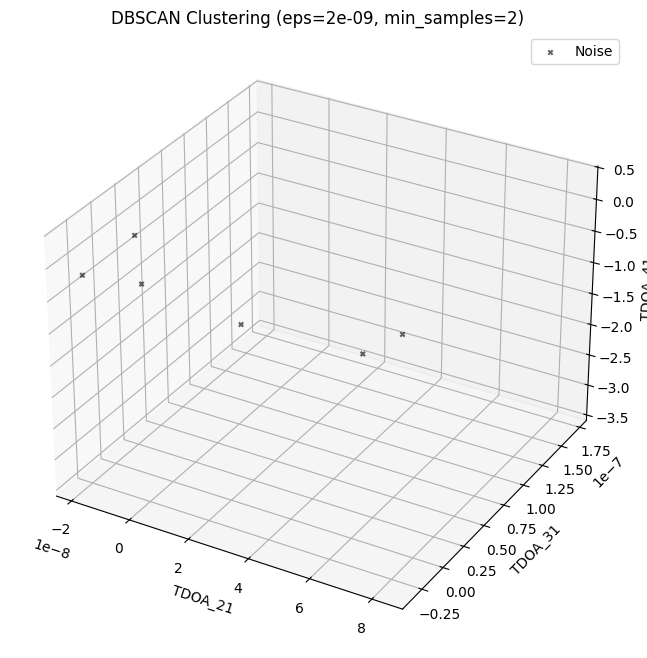

In [22]:
import matplotlib.pyplot as plt

print("Generating 3D Cluster Plot...")
    
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Get unique labels
unique_labels = set(clusters)

# Define colors (using a colormap)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise, similar to unclassified points in paper figures
        col = [0, 0, 0, 1]
        label = "Noise"
        marker = 'x'
        size = 10
    else:
        label = f"Cluster {k}"
        marker = 'o'
        size = 20

    # Select data for this cluster
    class_member_mask = (clusters == k)
    xyz = X[class_member_mask]
    
    ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], 
                c=[col], s=size, label=label, marker=marker, alpha=0.6)

ax.set_xlabel('TDOA_21')
ax.set_ylabel('TDOA_31')
ax.set_zlabel('TDOA_41')
ax.set_title(f'DBSCAN Clustering (eps={epsilon}, min_samples={min_samples})')
ax.legend()

plt.show()

In [23]:
# Calculate mean TDOA and Actual coordinates for each cluster
cluster_means = TDOA_results_df[TDOA_results_df['cluster (DBSCAN -> PSO)'] != -1].groupby('cluster (DBSCAN -> PSO)').mean()

# Prepare data for PSO: Actual_X, Actual_Y, Actual_Z, TDOA_21, TDOA_31, TDOA_41
# The columns in cluster_means will be Group, TDOA_21, TDOA_31, TDOA_41, Actual_X, Actual_Y, Actual_Z
pso_input_data = cluster_means[['Actual_X', 'Actual_Y', 'Actual_Z', 'TDOA_21', 'TDOA_31', 'TDOA_41']].to_numpy()

print(f"Running PSO for {len(cluster_means)} clusters...")
import PSO as pso
cluster_pso_results = pso.pso_algorithm(pso_input_data)

# Convert results to DataFrame for display
cluster_pso_df = pd.DataFrame(cluster_pso_results)
# Add cluster ID back
cluster_pso_df['cluster'] = cluster_means.index.tolist()

print("\nPSO Results for Cluster Means:")
display(cluster_pso_df[['cluster', 'estimated_location', 'true_location', 'euclidean_distance', 'percentage_error']])


Running PSO for 0 clusters...


KeyboardInterrupt: 

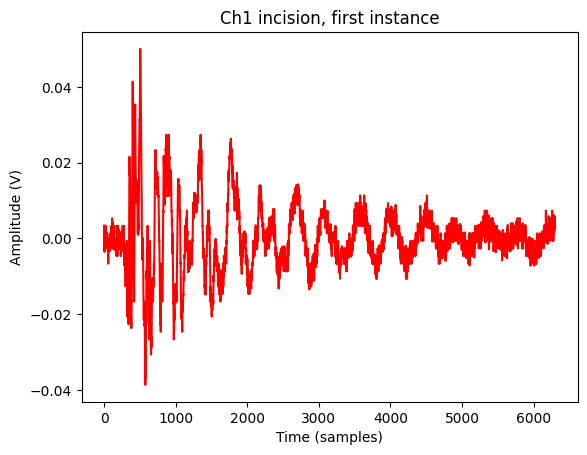

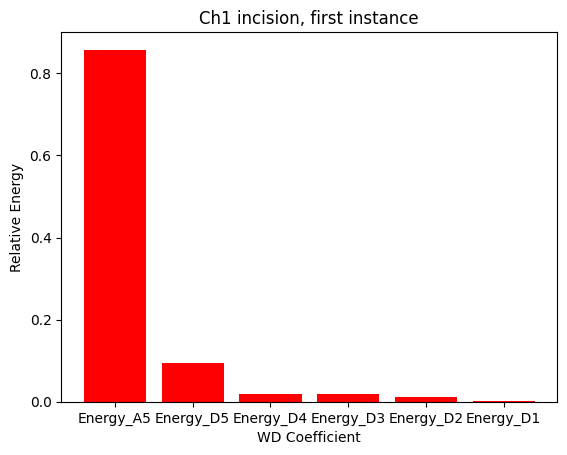

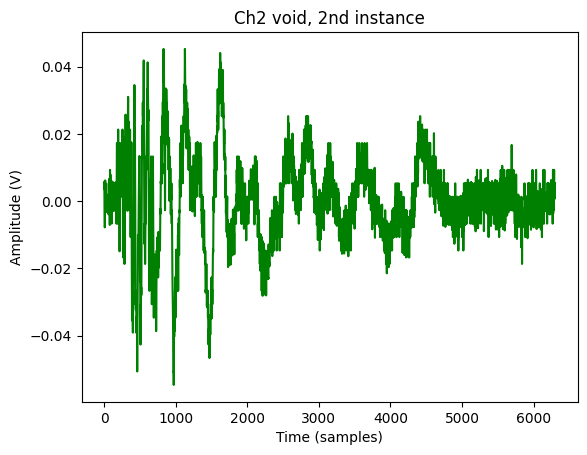

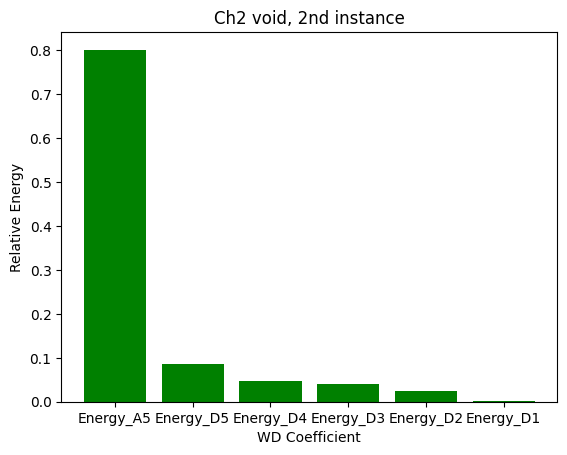

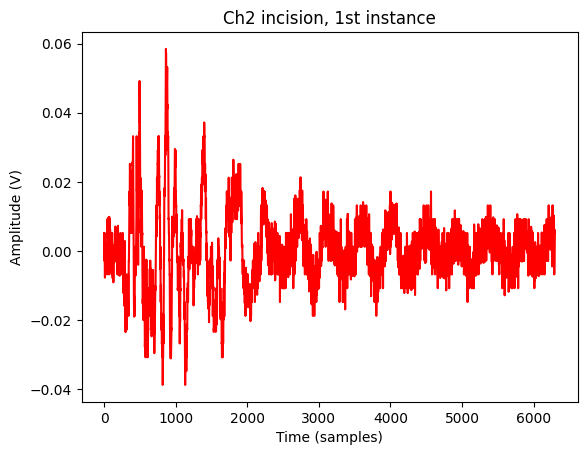

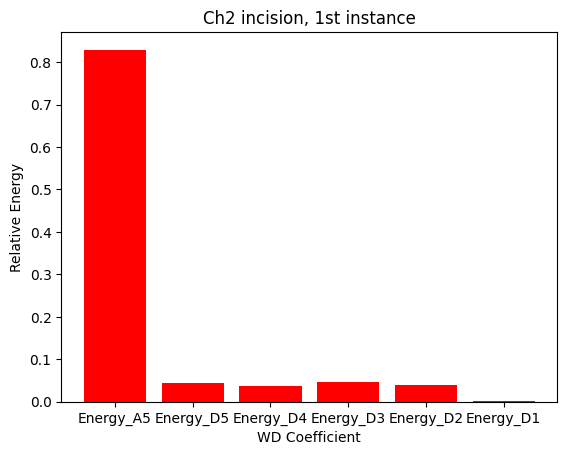

In [58]:
import Envelope_Analysis as ea
row = indices_df[(indices_df['input filename'] == 'Ch1.csv') & (indices_df['count'] == 1)]
signal = ea.load_waveform('Ch1.csv', row['start idx'].iloc[0], row['end idx'].iloc[0], channel_dataframes)
plt.figure()
plt.plot(signal, color='red')
plt.title('Ch1 incision, first instance')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude (V)')
plt.show()

pca_values = row[['Energy_A5', 'Energy_D5', 'Energy_D4', 'Energy_D3', 'Energy_D2','Energy_D1']].values
plt.figure()
plt.bar(['Energy_A5', 'Energy_D5', 'Energy_D4', 'Energy_D3', 'Energy_D2','Energy_D1'],pca_values[0], color='red')
plt.title('Ch1 incision, first instance')
plt.xlabel('WD Coefficient')
plt.ylabel(r'Relative Energy')
plt.show()

row = indices_df[(indices_df['input filename'] == 'Ch2.csv') & (indices_df['count'] == 5)]
signal = ea.load_waveform('Ch2.csv', row['start idx'].iloc[0], row['end idx'].iloc[0], channel_dataframes)
plt.figure()
plt.plot(signal, color = 'green')
plt.title('Ch2 void, 2nd instance')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude (V)')
plt.show()

pca_values = row[['Energy_A5', 'Energy_D5', 'Energy_D4', 'Energy_D3', 'Energy_D2','Energy_D1']].values
plt.figure()
plt.bar(['Energy_A5', 'Energy_D5', 'Energy_D4', 'Energy_D3', 'Energy_D2','Energy_D1'],pca_values[0], color = 'green')
plt.title('Ch2 void, 2nd instance')
plt.xlabel('WD Coefficient')
plt.ylabel(r'Relative Energy')
plt.show()


row = indices_df[(indices_df['input filename'] == 'Ch2.csv') & (indices_df['count'] == 1)]
signal = ea.load_waveform('Ch2.csv', row['start idx'].iloc[0], row['end idx'].iloc[0], channel_dataframes)
plt.figure()
plt.plot(signal, color='red')
plt.title('Ch2 incision, 1st instance')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude (V)')
plt.show()

pca_values = row[['Energy_A5', 'Energy_D5', 'Energy_D4', 'Energy_D3', 'Energy_D2','Energy_D1']].values
plt.figure()
plt.bar(['Energy_A5', 'Energy_D5', 'Energy_D4', 'Energy_D3', 'Energy_D2','Energy_D1'],pca_values[0], color='red')
plt.title('Ch2 incision, 1st instance')
plt.xlabel('WD Coefficient')
plt.ylabel(r'Relative Energy')
plt.show()




Performing Wavelet Decomposition on Ch1 signal...


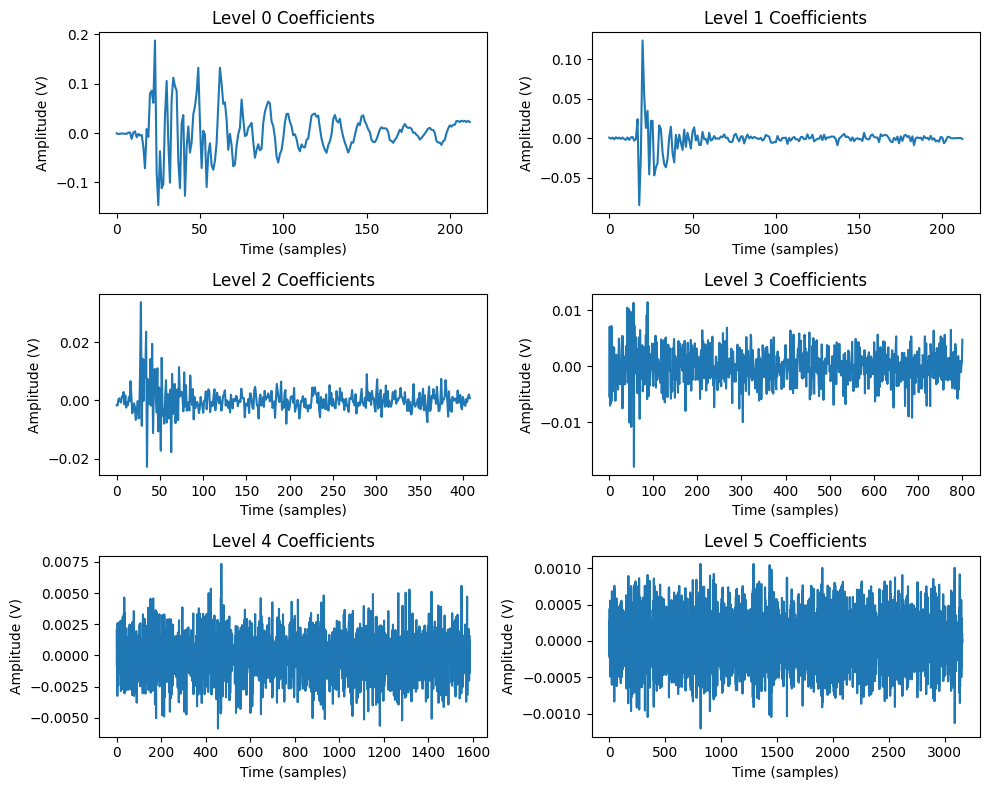

In [52]:
import pywt
import Envelope_Analysis as ea
import matplotlib.pyplot as plt

# Ensure variables exist
if 'indices_df' in locals() and 'channel_dataframes' in locals():
    print("Performing Wavelet Decomposition on Ch1 signal...")
    
    # Select specific row
    row = indices_df[(indices_df['input filename'] == 'Ch1.csv') & (indices_df['count'] == 1)]
    
    if not row.empty:
        # Load waveform
        signal = ea.load_waveform('Ch1.csv', row['start idx'].iloc[0], row['end idx'].iloc[0], channel_dataframes)

        # Decompose
        coeffs = pywt.wavedec(signal, 'sym9', level=5)

        # Plotting
        # Fixed: Use fig, ax to avoid shadowing 'plt'
        fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(10, 8))
        ax = ax.flatten() # Fixed: Flatten 2D axes array for 1D iteration

        for idx, c in enumerate(coeffs):
            if idx < len(ax):
                ax[idx].plot(c)
                ax[idx].set_title(f'Level {idx} Coefficients')
                ax[idx].set_xlabel('Time (samples)')
                ax[idx].set_ylabel('Amplitude (V)')
        
        plt.tight_layout()
        plt.show()
    else:
        print("No matching row found for Ch1 count 1")
else:
    print("Error: indices_df or channel_dataframes missing. Run previous notebook cells first.")

Performing Wavelet Decomposition on Ch2 signal...


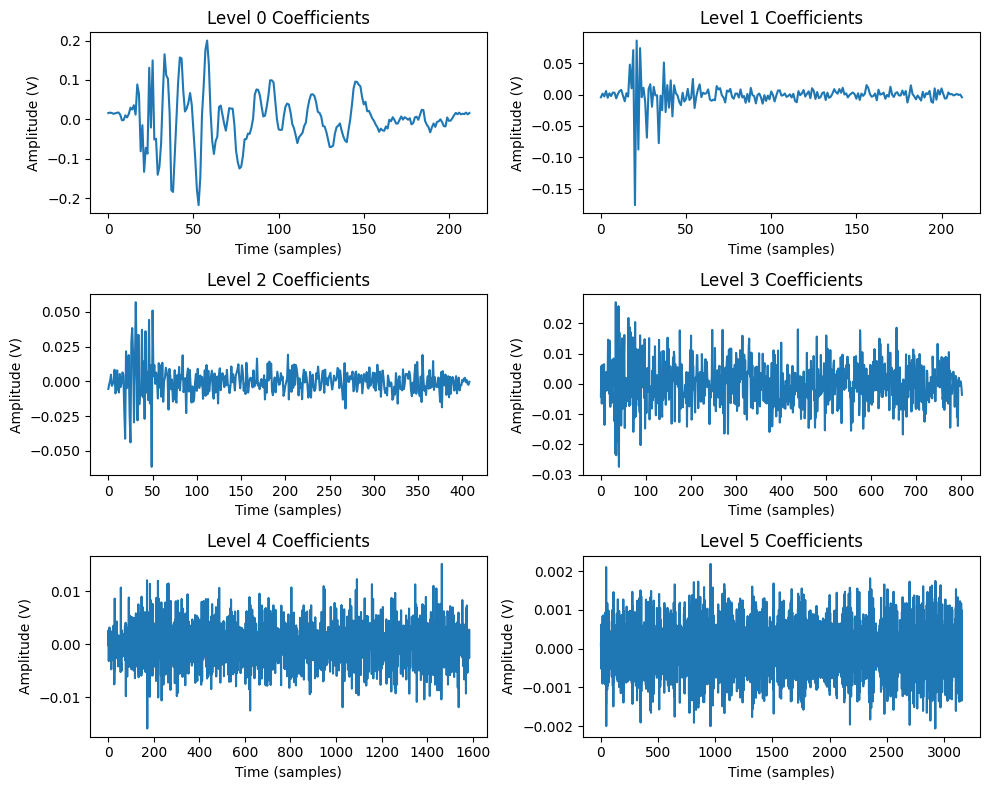

In [54]:
import pywt
import Envelope_Analysis as ea
import matplotlib.pyplot as plt

# Ensure variables exist
if 'indices_df' in locals() and 'channel_dataframes' in locals():
    print("Performing Wavelet Decomposition on Ch2 signal...")
    
    # Select specific row
    row = indices_df[(indices_df['input filename'] == 'Ch2.csv') & (indices_df['count'] == 5)]
    
    if not row.empty:
        # Load waveform
        signal = ea.load_waveform('Ch2.csv', row['start idx'].iloc[0], row['end idx'].iloc[0], channel_dataframes)

        # Decompose
        coeffs = pywt.wavedec(signal, 'sym9', level=5)

        # Plotting
        # Fixed: Use fig, ax to avoid shadowing 'plt'
        fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(10, 8))
        ax = ax.flatten() # Fixed: Flatten 2D axes array for 1D iteration

        for idx, c in enumerate(coeffs):
            if idx < len(ax):
                ax[idx].plot(c)
                ax[idx].set_title(f'Level {idx} Coefficients')
                ax[idx].set_xlabel('Time (samples)')
                ax[idx].set_ylabel('Amplitude (V)')
        
        plt.tight_layout()
        plt.show()
    else:
        print("No matching row found for Ch1 count 1")
else:
    print("Error: indices_df or channel_dataframes missing. Run previous notebook cells first.")

Performing Wavelet Decomposition on Ch2 signal...


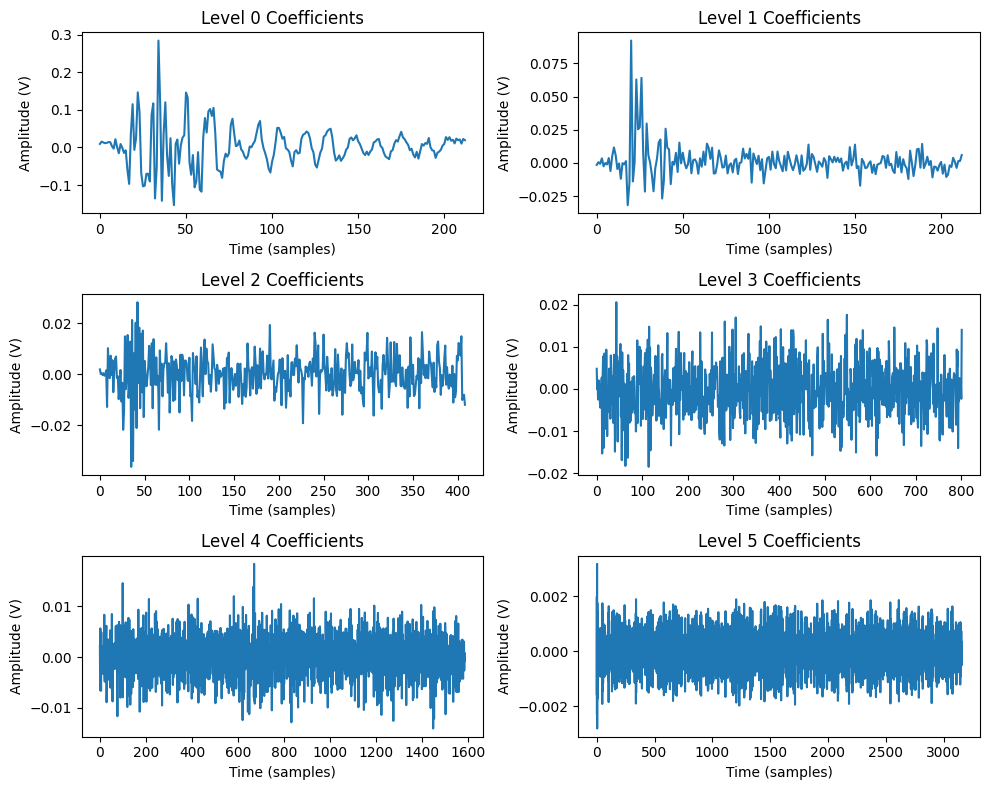

In [57]:
import pywt
import Envelope_Analysis as ea
import matplotlib.pyplot as plt

# Ensure variables exist
if 'indices_df' in locals() and 'channel_dataframes' in locals():
    print("Performing Wavelet Decomposition on Ch2 signal...")
    
    # Select specific row
    row = indices_df[(indices_df['input filename'] == 'Ch2.csv') & (indices_df['count'] == 1)]
    
    if not row.empty:
        # Load waveform
        signal = ea.load_waveform('Ch2.csv', row['start idx'].iloc[0], row['end idx'].iloc[0], channel_dataframes)

        # Decompose
        coeffs = pywt.wavedec(signal, 'sym9', level=5)

        # Plotting
        # Fixed: Use fig, ax to avoid shadowing 'plt'
        fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(10, 8))
        ax = ax.flatten() # Fixed: Flatten 2D axes array for 1D iteration

        for idx, c in enumerate(coeffs):
            if idx < len(ax):
                ax[idx].plot(c)
                ax[idx].set_title(f'Level {idx} Coefficients')
                ax[idx].set_xlabel('Time (samples)')
                ax[idx].set_ylabel('Amplitude (V)')
        
        plt.tight_layout()
        plt.show()
    else:
        print("No matching row found for Ch1 count 1")
else:
    print("Error: indices_df or channel_dataframes missing. Run previous notebook cells first.")

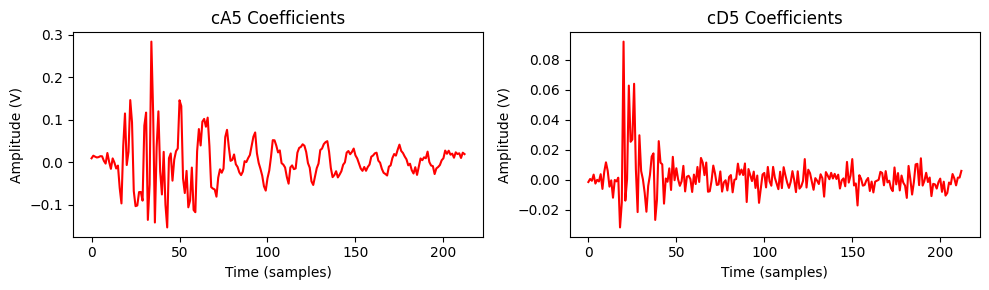

In [69]:
import pywt
import Envelope_Analysis as ea
import matplotlib.pyplot as plt

    
# Select specific row
row = indices_df[(indices_df['input filename'] == 'Ch2.csv') & (indices_df['count'] == 1)]
    
# Load waveform
signal = ea.load_waveform('Ch2.csv', row['start idx'].iloc[0], row['end idx'].iloc[0], channel_dataframes)

# Decompose
coeffs = pywt.wavedec(signal, 'sym9', level=5)

# Plotting
# Fixed: Use fig, ax to avoid shadowing 'plt'
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 3))
ax = ax.flatten() # Fixed: Flatten 2D axes array for 1D iteration

ax[0].plot(coeffs[0], color='red')
ax[0].set_title(f'cA5 Coefficients')
ax[0].set_xlabel('Time (samples)')
ax[0].set_ylabel('Amplitude (V)')

ax[1].plot(coeffs[1], color='red')
ax[1].set_title(f'cD5 Coefficients')
ax[1].set_xlabel('Time (samples)')
ax[1].set_ylabel('Amplitude (V)')

plt.tight_layout()
plt.show()
    